# Figure 2: modeled TCN responses under fixed and fluctuating selection

This notebook generates the simulation panels of Figure 2. The model and shared parameters are defined in `simulation_core.ipynb`. The primary model uses a persistent one-copy chromosomal floor and maximum PCN capacity $n=100$.


In [1]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("SIM_RUN_MODE", "production")
%run ./simulation_core.ipynb
plt.rcParams.update(PLOT_STYLE)

MAX_PCN = 100
CONFIGS = standard_configurations(MAX_PCN)
OUTPUT_ROOT, FIGURE_DIR, SOURCE_DIR = make_output_dirs("Figure2_outputs")


## Figure 2d: imposed TCN-growth relationships


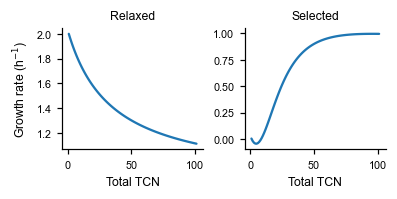

In [2]:
tcn = total_tcn_states(MAX_PCN)
relaxed_growth = growth_rates(MAX_PCN, selected=False)
selected_growth = growth_rates(MAX_PCN, selected=True)

fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.7), sharex=True, constrained_layout=True)
axes[0].plot(tcn, relaxed_growth)
axes[1].plot(tcn, selected_growth)
axes[0].set_title("Relaxed")
axes[1].set_title("Selected")
for ax in axes:
    ax.set_xlabel("Total TCN")
axes[0].set_ylabel("Growth rate (h$^{-1}$)")
save_figure(fig, "Figure2d_growth", FIGURE_DIR)
plt.show()

export_table(pd.DataFrame({"total_TCN": tcn, "relaxed_growth_h-1": relaxed_growth,
                           "selected_growth_h-1": selected_growth}),
             "Figure2d_source_data.csv", SOURCE_DIR)


## Figure 2e: fixed environments

The relaxed trajectory is simulated for five daily passages from the fixed-loss initialization. The selected trajectory is simulated for two daily passages from the fixed-gain initialization.


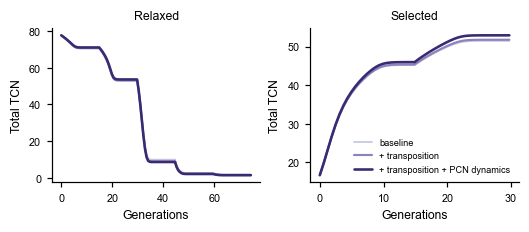

In [3]:
fixed_frames=[]
for config in CONFIGS:
    for phase, duration, init in (
        ("loss", RELAXED_DAYS_PER_CYCLE, fixed_loss_initial_state(MAX_PCN)),
        ("gain", SELECTED_DAYS_PER_CYCLE, fixed_gain_initial_state(MAX_PCN)),
    ):
        traj, daily, _, summary = simulate_phase(
            MAX_PCN, config, phase=phase, duration_days=duration,
            initial_state=init.copy(), record_trajectory=True,
        )
        traj["phase"] = phase
        fixed_frames.append(traj)
fixed = pd.concat(fixed_frames, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(4.7, 2.0), constrained_layout=True)
for ax, phase, title in zip(axes, ("loss", "gain"), ("Relaxed", "Selected")):
    for config in CONFIGS:
        d=fixed[(fixed.phase==phase) & (fixed.condition==config.condition)]
        ax.plot(d.phase_day*PASSAGE_GENERATIONS, d.TCN_per_density,
                color=CONDITION_COLORS[config.condition],
                lw=CONDITION_LINEWIDTHS[config.condition],
                label=DISPLAY_LABELS[config.condition])
    ax.set_title(title)
    ax.set_xlabel("Generations")
    ax.set_ylabel("Total TCN")
axes[1].legend(frameon=False, fontsize=6)
save_figure(fig, "Figure2e_fixed_environments", FIGURE_DIR)
plt.show()
export_table(fixed, "Figure2e_source_data.csv", SOURCE_DIR)


## Figure 2f–g: converged fluctuating selection

Each configuration is iterated to periodic convergence under five relaxed passages followed by two selected passages. Three additional cycles are simulated after convergence; the final cycle supplies the response rates.


In [4]:
periodic_frames=[]
summary_rows=[]
for config in CONFIGS:
    conv = converge_periodic_state(MAX_PCN, config, periodic_initial_state(MAX_PCN))
    if not conv["converged"]:
        raise RuntimeError(f"Figure 2 did not converge for {config.condition}")
    traj, post = simulate_post_convergence_cycles(MAX_PCN, config, conv["state"])
    periodic_frames.append(traj)
    summary_rows.append({
        "condition": config.condition,
        "cycles_to_convergence": conv["cycles_to_convergence"],
        **post["reported"],
    })
periodic = pd.concat(periodic_frames, ignore_index=True)
summary = pd.DataFrame(summary_rows)


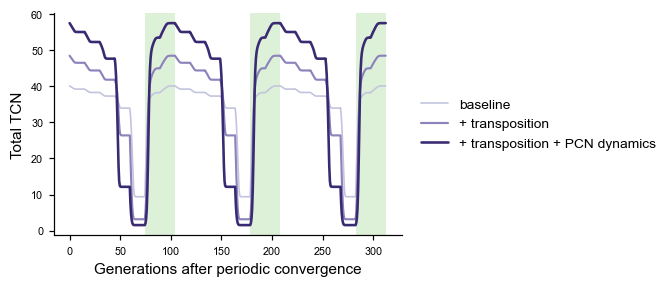

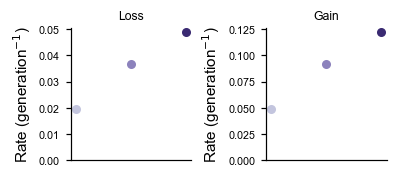

In [22]:
fig, ax = plt.subplots(figsize=(6.0, 2.5), constrained_layout=True)
for cycle in range(1, ADDITIONAL_CYCLES_AFTER_CONVERGENCE+1):
    start=(cycle-1)*DAYS_PER_CYCLE+RELAXED_DAYS_PER_CYCLE
    ax.axvspan(start*PASSAGE_GENERATIONS,
               (start+SELECTED_DAYS_PER_CYCLE)*PASSAGE_GENERATIONS,
               color=SELECTION_SHADE, lw=0, zorder=0)
for config in CONFIGS:
    d=periodic[periodic.condition==config.condition]
    ax.plot(d.Day*PASSAGE_GENERATIONS, d.TCN_per_density,
            color=CONDITION_COLORS[config.condition],
            lw=CONDITION_LINEWIDTHS[config.condition],
            label=DISPLAY_LABELS[config.condition])
ax.set_xlabel("Generations after periodic convergence", fontsize = 10)
ax.set_ylabel("Total TCN", fontsize = 10)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=9,
)

save_figure(fig, "Figure2f_fluctuating", FIGURE_DIR)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.5), constrained_layout=True)
for ax, metric, title in zip(axes, ("loss_rate","gain_rate"), ("Loss","Gain")):
    for x, condition in enumerate(CONDITION_ORDER):
        row=summary[summary.condition==condition].iloc[0]
        ax.scatter(x, row[metric], color=CONDITION_COLORS[condition], s=24)
    ax.set_title(title)
    ax.set_ylabel("Rate (generation$^{-1}$)", fontsize = 10)
    ax.set_xticks([])
    ax.set_ylim(bottom=0)
save_figure(fig, "Figure2g_response_rates", FIGURE_DIR)
plt.show()

export_table(periodic, "Figure2f_source_data.csv", SOURCE_DIR)
export_table(summary, "Figure2g_source_data.csv", SOURCE_DIR)
export_table(core_metadata("Figure 2"), "Figure2_run_metadata.csv", SOURCE_DIR)